# Preprocesamiento: Series temporales de vitalsign para LSTM

**Objetivo:** Construir secuencias de constantes vitales de las primeras 2 horas de cada visita a urgencias para alimentar el modelo LSTM.  
**Fuente:** Tabla `vitalsign` (MIMIC-IV-ED) + vitales del triage (ya en los parquets) como t=0.  
**Salidas:** `data/processed/lstm_sequences_{train,val,test}.npz` + `data/processed/lstm_stats.json`

**Estructura de la secuencia por estancia:**
- `t=0`: vitales del triage (ya disponibles en el parquet, siempre presentes).
- `t=1,2,...`: mediciones de `vitalsign` dentro de las primeras 2h desde `intime`.
- Garantiza `seq_len ≥ 1` para todos los pacientes de la cohorte.

## 1. Setup

Carga de librerías, rutas y parámetros del pipeline (ventana temporal, columnas de vitales).

In [3]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from tqdm.auto import tqdm

# Buscar .env subiendo desde CWD (funciona independientemente de donde se lance Jupyter)
_cur = Path.cwd()
while not (_cur / ".env").exists() and _cur != _cur.parent:
    _cur = _cur.parent
load_dotenv(_cur / ".env", override=True)

DATA          = Path(os.getenv("MIMIC_IV_ED_PATH", ""))
PROCESSED_DIR = (DATA / "processed").resolve()

# Parametros
VITAL_COLS      = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp"]
TIME_WINDOW_MIN = 120   # ventana temporal: primeras 2 horas

# Bounds fisiologicos identicos a los aplicados en 03_verify_build_labels
VITAL_BOUNDS = {
    "temperature": (85.0, 115.0),
    "heartrate":   (0.0,  300.0),
    "resprate":    (0.0,   60.0),
    "o2sat":       (50.0, 100.0),
    "sbp":         (0.0,  300.0),
    "dbp":         (0.0,  200.0),
}

print(f"DATA         : {DATA}  |  existe: {DATA.exists()}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")
print(f"Vitales      : {VITAL_COLS}")
print(f"Ventana      : {TIME_WINDOW_MIN} min")

DATA         : C:\Users\cuent\Documents\UAX\TFM\TFM\CodigoGit\data  |  existe: True
PROCESSED_DIR: C:\Users\cuent\Documents\UAX\TFM\TFM\CodigoGit\data\processed
Vitales      : ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']
Ventana      : 120 min


## 2. Carga de datos

Se leen los parquets del split temporal y la tabla `vitalsign`. Las mediciones se filtran a la cohorte y a la ventana de 0-120 min desde `intime`.

In [4]:
print("Cargando parquets del split temporal...")
df_train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
df_val   = pd.read_parquet(PROCESSED_DIR / "val.parquet")
df_test  = pd.read_parquet(PROCESSED_DIR / "test.parquet")

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"  {name}: {df.shape[0]:,} estancias")

# intime como datetime (para calcular elapsed)
for df in [df_train, df_val, df_test]:
    df["intime"] = pd.to_datetime(df["intime"])

# Lookup stay_id → intime para todo el dataset
all_stays = pd.concat([
    df_train[["stay_id", "intime"]],
    df_val[["stay_id", "intime"]],
    df_test[["stay_id", "intime"]],
])
cohort_stay_ids = set(all_stays["stay_id"])
print(f"\nTotal estancias en cohorte: {len(cohort_stay_ids):,}")

Cargando parquets del split temporal...
  train: 278,320 estancias
  val: 59,640 estancias
  test: 59,641 estancias

Total estancias en cohorte: 397,601


In [5]:
print("Cargando vitalsign.csv (puede tardar 30-60s)...")
vs = pd.read_csv(DATA / "vitalsign.csv", low_memory=False,
                 usecols=["stay_id", "charttime"] + VITAL_COLS)
vs["charttime"] = pd.to_datetime(vs["charttime"])
print(f"vitalsign shape: {vs.shape}")

# Aplicar bounds fisiologicos identicos a los del pipeline de cohorte
n_before = vs[VITAL_COLS].notna().sum().sum()
for col, (lo, hi) in VITAL_BOUNDS.items():
    if col not in vs.columns:
        continue
    mask = vs[col].notna() & ((vs[col] < lo) | (vs[col] > hi))
    vs.loc[mask, col] = float("nan")
n_after = vs[VITAL_COLS].notna().sum().sum()
print(f"Outliers fisiologicos eliminados de vitalsign: {n_before - n_after:,}")

# Filtrar a la cohorte
vs = vs[vs["stay_id"].isin(cohort_stay_ids)].copy()
print(f"Tras filtrar a cohorte: {vs.shape[0]:,} filas")

# Merge con intime y calcular tiempo transcurrido
vs = vs.merge(all_stays, on="stay_id", how="left")
vs["elapsed_min"] = (vs["charttime"] - vs["intime"]).dt.total_seconds() / 60

# Filtrar: solo mediciones dentro de la ventana temporal (>=0 y <=120 min)
vs = vs[(vs["elapsed_min"] >= 0) & (vs["elapsed_min"] <= TIME_WINDOW_MIN)].copy()
vs = vs.sort_values(["stay_id", "elapsed_min"])
print(f"Tras filtro 0-{TIME_WINDOW_MIN} min: {vs.shape[0]:,} filas")

Cargando vitalsign.csv (puede tardar 30-60s)...
vitalsign shape: (1564610, 8)
Outliers fisiologicos eliminados de vitalsign: 6,639
Tras filtrar a cohorte: 1,482,018 filas
Tras filtro 0-120 min: 443,591 filas


## 3. Análisis de longitud de secuencias

Se analiza la distribución del número de mediciones por estancia en el conjunto de entrenamiento para determinar el valor óptimo de `MAX_LEN`. El análisis se restringe al split de train para evitar cualquier forma de contaminación con los datos de validación y test.

Distribución de longitud de secuencia (vitalsign + triage):
count    278320.0
mean          2.1
std           1.2
min           1.0
25%           1.0
50%           2.0
75%           2.0
90%           3.0
95%           4.0
99%           6.0
max          67.0
Name: n_vitalsign, dtype: float64

Estancias sin mediciones vitalsign (solo triage): 77,753 (27.9%)


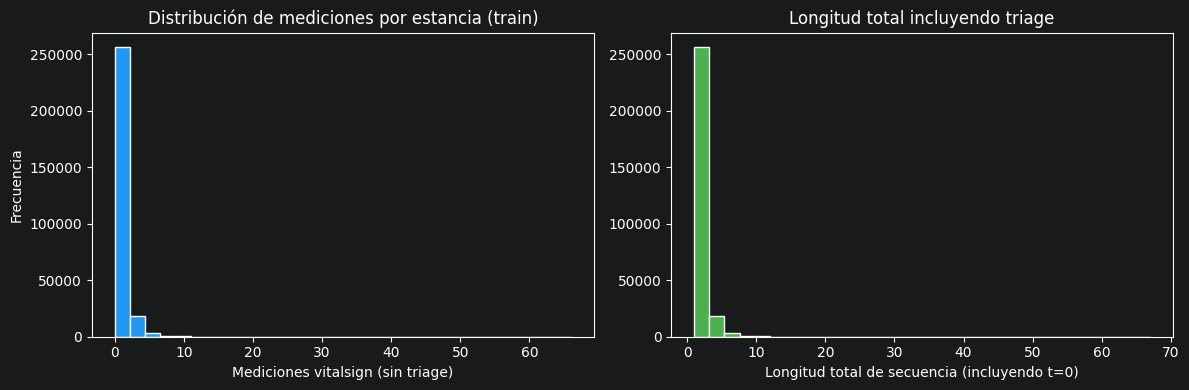


Percentil 95 longitud total: 4


In [6]:
# Se utiliza únicamente el split de train para evitar contaminación en las decisiones de diseño
vs_train = vs[vs["stay_id"].isin(set(df_train["stay_id"]))].copy()

seq_counts = vs_train.groupby("stay_id").size().rename("n_vitalsign")
all_train_stays = pd.Series(0, index=df_train["stay_id"], name="n_vitalsign")
seq_counts_full = all_train_stays.add(seq_counts, fill_value=0).astype(int)

# +1 por el triage (t=0 siempre presente)
seq_len_with_triage = seq_counts_full + 1

print("Distribución de longitud de secuencia (vitalsign + triage):")
print(seq_len_with_triage.describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(1))
print(f"\nEstancias sin mediciones vitalsign (solo triage): {(seq_counts_full == 0).sum():,} "
      f"({(seq_counts_full == 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(seq_counts_full, bins=30, color="#2196F3", edgecolor="white")
axes[0].set_xlabel("Mediciones vitalsign (sin triage)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de mediciones por estancia (train)")

axes[1].hist(seq_len_with_triage, bins=30, color="#4CAF50", edgecolor="white")
axes[1].set_xlabel("Longitud total de secuencia (incluyendo t=0)")
axes[1].set_title("Longitud total incluyendo triage")

plt.tight_layout()
plt.show()

# Decisión de MAX_LEN basada en el percentil 95
p95 = int(np.ceil(seq_len_with_triage.quantile(0.95)))
print(f"\nPercentil 95 longitud total: {p95}")

In [7]:
# Se fija MAX_LEN en función del percentil 95; mínimo 10 para capturar suficiente señal temporal
MAX_LEN = max(p95, 10)
print(f"MAX_LEN fijado a: {MAX_LEN}")
print(f"Secuencias que se truncarán (>MAX_LEN): "
      f"{(seq_len_with_triage > MAX_LEN).sum():,} "
      f"({(seq_len_with_triage > MAX_LEN).mean()*100:.1f}%)")

MAX_LEN fijado a: 10
Secuencias que se truncarán (>MAX_LEN): 358 (0.1%)


## 4. Estadísticas de normalización (solo sobre train)

Se calculan media y desviación estándar sobre todos los valores de train (triage + vitalsign) para normalizar las secuencias.

In [8]:
# Combinar valores de triage (train) y vitalsign (train) para estimar distribución
triage_vals_train = df_train[VITAL_COLS]
vs_vals_train     = vs_train[VITAL_COLS]

all_train_vitals = pd.concat([triage_vals_train, vs_vals_train], ignore_index=True)

vital_means = all_train_vitals.mean().values.astype(np.float32)
vital_stds  = all_train_vitals.std().values.astype(np.float32)
vital_stds  = np.where(vital_stds < 1e-6, 1.0, vital_stds)  # evitar división por cero

print("Estadísticas de normalización (train):")
stats_df = pd.DataFrame({"feature": VITAL_COLS, "mean": vital_means, "std": vital_stds})
print(stats_df.round(3).to_string(index=False))

# Guardar en JSON para uso en el notebook de entrenamiento
lstm_stats = {
    "vital_cols":  VITAL_COLS,
    "vital_means": vital_means.tolist(),
    "vital_stds":  vital_stds.tolist(),
    "max_len":     int(MAX_LEN),
    "time_window_min": int(TIME_WINDOW_MIN),
}
with open(PROCESSED_DIR / "lstm_stats.json", "w") as f:
    json.dump(lstm_stats, f, indent=2)
print("\nGuardado: lstm_stats.json")

Estadísticas de normalización (train):
    feature       mean    std
temperature  98.119003  1.008
  heartrate  85.077003 18.691
   resprate  17.774000  2.923
      o2sat  98.252998  2.208
        sbp 133.216995 23.277
        dbp  76.362999 15.236

Guardado: lstm_stats.json


## 5. Construcción de secuencias

Función `build_sequences` que genera arrays `(n, MAX_LEN, n_feats)` con zero-padding y longitudes reales por estancia. Se aplica a los tres splits.

In [9]:
def build_sequences(df_split, vs_global, vital_cols, vital_means, vital_stds, max_len):
    """
    Construye (X_seq, seq_len) alineado con el orden de df_split.

    X_seq  : (n_stays, max_len, n_feats) — secuencia normalizada, 0-padded
    seq_len: (n_stays,)                  — longitud real de cada secuencia (≥ 1)
    """
    n_stays = len(df_split)
    n_feat  = len(vital_cols)
    X_seq   = np.zeros((n_stays, max_len, n_feat), dtype=np.float32)
    seq_len = np.ones(n_stays, dtype=np.int32)  # mínimo 1 (triage)

    # ── t = 0: triage (vectorizado) ──────────────────────────────────────────
    triage_arr = df_split[vital_cols].values.astype(np.float32)
    for j in range(n_feat):
        nan_mask = np.isnan(triage_arr[:, j])
        triage_arr[nan_mask, j] = vital_means[j]
    X_seq[:, 0, :] = (triage_arr - vital_means) / vital_stds

    # ── t > 0: vitalsign (lookup por stay_id) ────────────────────────────────
    split_ids = set(df_split["stay_id"])
    vs_split  = vs_global[vs_global["stay_id"].isin(split_ids)].copy()

    # Pre-construir lookup {stay_id: array (T, n_feat)} — solo max_len-1 filas
    vs_lookup = {}
    for stay_id, group in vs_split.groupby("stay_id"):
        rows = group[vital_cols].values.astype(np.float32)
        for j in range(n_feat):
            nan_mask = np.isnan(rows[:, j])
            rows[nan_mask, j] = vital_means[j]
        rows_norm = (rows - vital_means) / vital_stds
        vs_lookup[stay_id] = rows_norm[: max_len - 1]

    # Rellenar X_seq fila a fila
    for i, stay_id in enumerate(tqdm(df_split["stay_id"].values, desc="Secuencias", leave=False)):
        vs_rows = vs_lookup.get(stay_id)
        if vs_rows is not None and len(vs_rows) > 0:
            n_vs = len(vs_rows)
            X_seq[i, 1 : 1 + n_vs, :] = vs_rows
            seq_len[i] = 1 + n_vs

    return X_seq, seq_len

In [10]:
vs_val  = vs[vs["stay_id"].isin(set(df_val["stay_id"]))]
vs_test = vs[vs["stay_id"].isin(set(df_test["stay_id"]))]

print("Construyendo secuencias de TRAIN...")
X_seq_train, seq_len_train = build_sequences(
    df_train, vs_train, VITAL_COLS, vital_means, vital_stds, MAX_LEN)
print(f"  X_seq_train : {X_seq_train.shape}  |  seq_len media: {seq_len_train.mean():.2f}")

print("Construyendo secuencias de VAL...")
X_seq_val, seq_len_val = build_sequences(
    df_val, vs_val, VITAL_COLS, vital_means, vital_stds, MAX_LEN)
print(f"  X_seq_val   : {X_seq_val.shape}  |  seq_len media: {seq_len_val.mean():.2f}")

print("Construyendo secuencias de TEST...")
X_seq_test, seq_len_test = build_sequences(
    df_test, vs_test, VITAL_COLS, vital_means, vital_stds, MAX_LEN)
print(f"  X_seq_test  : {X_seq_test.shape}  |  seq_len media: {seq_len_test.mean():.2f}")

Construyendo secuencias de TRAIN...


Secuencias:   0%|          | 0/278320 [00:00<?, ?it/s]

  X_seq_train : (278320, 10, 6)  |  seq_len media: 2.11
Construyendo secuencias de VAL...


Secuencias:   0%|          | 0/59640 [00:00<?, ?it/s]

  X_seq_val   : (59640, 10, 6)  |  seq_len media: 2.10
Construyendo secuencias de TEST...


Secuencias:   0%|          | 0/59641 [00:00<?, ?it/s]

  X_seq_test  : (59641, 10, 6)  |  seq_len media: 2.11


## 6. Guardado

Se serializan los arrays de secuencias y el JSON de estadísticas de normalización en `data/processed/`.

In [11]:
np.savez_compressed(
    PROCESSED_DIR / "lstm_sequences_train.npz",
    X_seq=X_seq_train, seq_len=seq_len_train,
)
np.savez_compressed(
    PROCESSED_DIR / "lstm_sequences_val.npz",
    X_seq=X_seq_val, seq_len=seq_len_val,
)
np.savez_compressed(
    PROCESSED_DIR / "lstm_sequences_test.npz",
    X_seq=X_seq_test, seq_len=seq_len_test,
)
print("Guardado:")
for name in ["lstm_sequences_train.npz", "lstm_sequences_val.npz",
             "lstm_sequences_test.npz", "lstm_stats.json"]:
    out_path = PROCESSED_DIR / name
    print(f"  {out_path.name:<35} {out_path.stat().st_size / 1024**2:.1f} MB")

Guardado:
  lstm_sequences_train.npz            5.1 MB
  lstm_sequences_val.npz              1.1 MB
  lstm_sequences_test.npz             1.1 MB
  lstm_stats.json                     0.0 MB


## 7. Verificación

Se comprueban la integridad de los artefactos generados: alineación de longitudes, ausencia de valores NaN y corrección del zero-padding en posiciones fuera de la secuencia real.

In [12]:
# Se verifica alineación, ausencia de NaN y corrección del padding
assert seq_len_train.min() >= 1, "ERROR: hay secuencias de longitud 0"
assert seq_len_val.min()   >= 1
assert seq_len_test.min()  >= 1

assert not np.isnan(X_seq_train).any(), "ERROR: NaN en X_seq_train"
assert not np.isnan(X_seq_val).any()
assert not np.isnan(X_seq_test).any()

for i in range(5):
    sl = seq_len_train[i]
    if sl < MAX_LEN:
        assert (X_seq_train[i, sl:, :] == 0).all(), f"Padding no-cero en fila {i}"

print("Todas las verificaciones correctas.")
print(f"\nResumen final:")
print(f"  X_seq_train : {X_seq_train.shape}  dtype={X_seq_train.dtype}")
print(f"  seq_len dist (train): min={seq_len_train.min()} | p50={np.median(seq_len_train):.0f} "
      f"| p95={np.percentile(seq_len_train, 95):.0f} | max={seq_len_train.max()}")
print(f"\nListo para el notebook de entrenamiento LSTM (04_lstm_model.ipynb).")

Todas las verificaciones correctas.

Resumen final:
  X_seq_train : (278320, 10, 6)  dtype=float32
  seq_len dist (train): min=1 | p50=2 | p95=4 | max=10

Listo para el notebook de entrenamiento LSTM (04_lstm_model.ipynb).
